In [8]:
# Uncomment to install
# !pip install torch torchvision transformers datasets fastapi uvicorn httpx pydantic joblib matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torchvision.datasets import CIFAR10
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, random_split

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForTokenClassification, pipeline,
    Trainer, TrainingArguments, DataCollatorWithPadding
)
from datasets import load_dataset

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import joblib

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('✅ All libraries imported!')
print(f'   PyTorch     : {torch.__version__}')
print(f'   Torchvision : {torchvision.__version__}')
print(f'   Device      : {DEVICE}')

✅ All libraries imported!
   PyTorch     : 2.10.0+cpu
   Torchvision : 0.25.0+cpu
   Device      : cpu


In [7]:
!pip install transformers
!pip install datasets


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 707.0 kB/s  0:00:00

   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   -------------------- ------------------- 2/4 [multiprocess]
   -------------------- ------------------- 2/4 [multiprocess]
   -------------------- ------------------- 2/4 [multiprocess]
   -------------------- ------------------- 2/4 [multiprocess]
   -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [9]:
# ── 1.1  Data Augmentation Pipelines ─────────────────────────────────────────
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

train_tf = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(32, padding=4),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])
val_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_ds = CIFAR10(root='./data', train=True,  download=True, transform=train_tf)
val_ds   = CIFAR10(root='./data', train=False, download=True, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2)

CLASSES = train_ds.classes
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Classes: {CLASSES}')

100%|████████████████████████████████████████████████████████████████████████████████| 170M/170M [03:37<00:00, 783kB/s]


Train: 50000 | Val: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


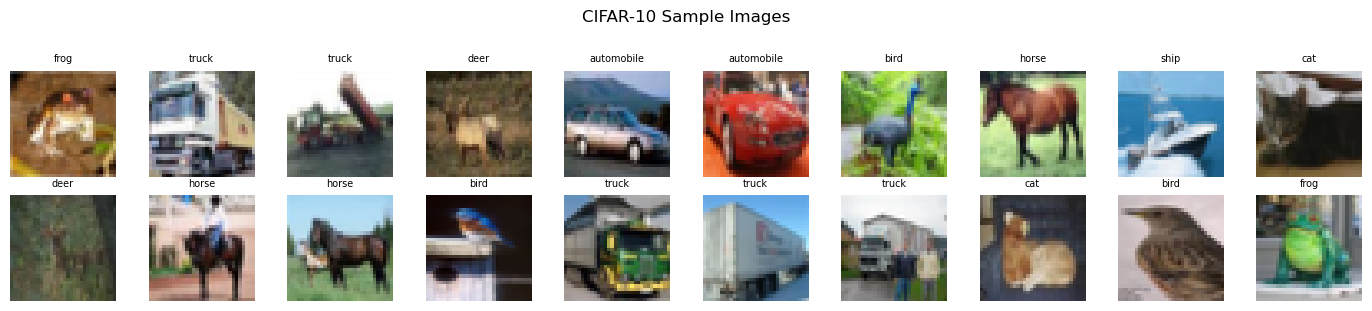

In [11]:
# ── 1.2  Visualise Sample Images ──────────────────────────────────────────────
raw_ds = CIFAR10(root='./data', train=True, download=False, transform=T.ToTensor())
imgs, labels = zip(*[raw_ds[i] for i in range(20)])

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, (img, lbl) in enumerate(zip(imgs, labels)):
    ax = axes[i // 10][i % 10]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(CLASSES[lbl], fontsize=7)
    ax.axis('off')
plt.suptitle('CIFAR-10 Sample Images', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# ── 1.3  Define CNN Architecture ─────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class ConvNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32, pool=True),   # 32→16
            ConvBlock(32,  64, pool=True),   # 16→8
            ConvBlock(64, 128, pool=False),  # 8→8 (no pool)
            ConvBlock(128,128, pool=True),   # 8→4
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


cnn = ConvNet().to(DEVICE)
total = sum(p.numel() for p in cnn.parameters())
print(cnn)
print(f'\nTotal parameters: {total:,}')

ConvNet(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

In [13]:
# ── 1.4  CNN Training Loop ────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-2,
    steps_per_epoch=len(train_loader), epochs=15
)
criterion = nn.CrossEntropyLoss()

train_losses, val_accs = [], []

for epoch in range(1, 16):
    cnn.train()
    running_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(cnn(imgs), lbls)
        loss.backward()
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()

    # Validation
    cnn.eval()
    correct = total_s = 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            preds = cnn(imgs).argmax(1)
            correct += (preds == lbls).sum().item()
            total_s += lbls.size(0)

    avg_loss = running_loss / len(train_loader)
    val_acc  = correct / total_s
    train_losses.append(avg_loss)
    val_accs.append(val_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>2} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}')

torch.save(cnn.state_dict(), 'cnn_cifar10.pt')
print('\n✅ CNN saved to cnn_cifar10.pt')

Epoch  1 | Loss: 1.5949 | Val Acc: 0.4658
Epoch  5 | Loss: 0.8399 | Val Acc: 0.7210
Epoch 10 | Loss: 0.5594 | Val Acc: 0.8091
Epoch 15 | Loss: 0.4098 | Val Acc: 0.8492

✅ CNN saved to cnn_cifar10.pt


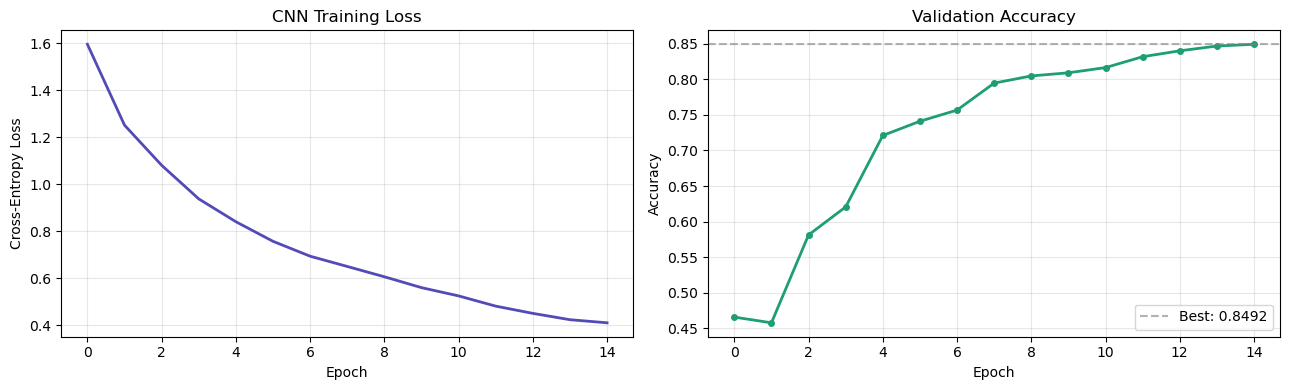

Final val accuracy: 0.8492


In [14]:
# ── 1.5  Training Curves + Per-Class Accuracy ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, color='#534AB7', linewidth=2)
axes[0].set_title('CNN Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(val_accs, color='#1D9E75', linewidth=2, marker='o', markersize=4)
axes[1].axhline(max(val_accs), linestyle='--', color='gray', alpha=0.6,
                label=f'Best: {max(val_accs):.4f}')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Final val accuracy: {val_accs[-1]:.4f}')

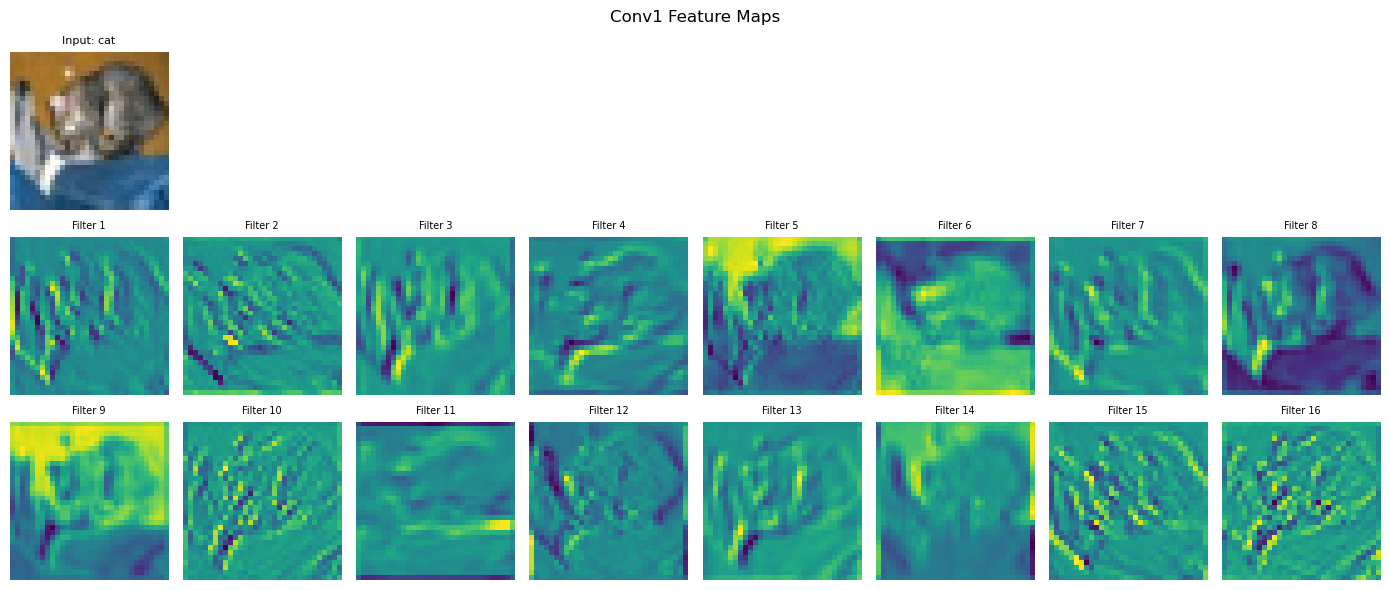

In [15]:
# ── 1.6  Feature Map Visualisation ───────────────────────────────────────────
# Get one test image
sample_img, sample_lbl = val_ds[0]
x = sample_img.unsqueeze(0).to(DEVICE)

# Hook to capture intermediate activations
activations = {}
def hook_fn(name):
    def hook(module, inp, out):
        activations[name] = out.detach().cpu()
    return hook

cnn.eval()
handle = cnn.features[0].block[0].register_forward_hook(hook_fn('conv1'))
with torch.no_grad():
    _ = cnn(x)
handle.remove()

# Visualise first 16 feature maps from conv1
fmaps = activations['conv1'][0]  # shape: (32, 32, 32)
fig, axes = plt.subplots(3, 8, figsize=(14, 6))

# Original image
axes[0][0].imshow(sample_img.permute(1,2,0).numpy() * np.array(CIFAR_STD) + np.array(CIFAR_MEAN))
axes[0][0].set_title(f'Input: {CLASSES[sample_lbl]}', fontsize=8)
axes[0][0].axis('off')
for i in range(1, 8):
    axes[0][i].axis('off')

for i in range(16):
    r, c = (i // 8) + 1, i % 8
    axes[r][c].imshow(fmaps[i].numpy(), cmap='viridis')
    axes[r][c].set_title(f'Filter {i+1}', fontsize=7)
    axes[r][c].axis('off')

plt.suptitle('Conv1 Feature Maps', fontsize=12)
plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

    airplane       0.84      0.87      0.85      1000
  automobile       0.94      0.93      0.93      1000
        bird       0.81      0.77      0.79      1000
         cat       0.73      0.71      0.72      1000
        deer       0.83      0.83      0.83      1000
         dog       0.77      0.79      0.78      1000
        frog       0.87      0.91      0.89      1000
       horse       0.89      0.87      0.88      1000
        ship       0.93      0.91      0.92      1000
       truck       0.89      0.92      0.91      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



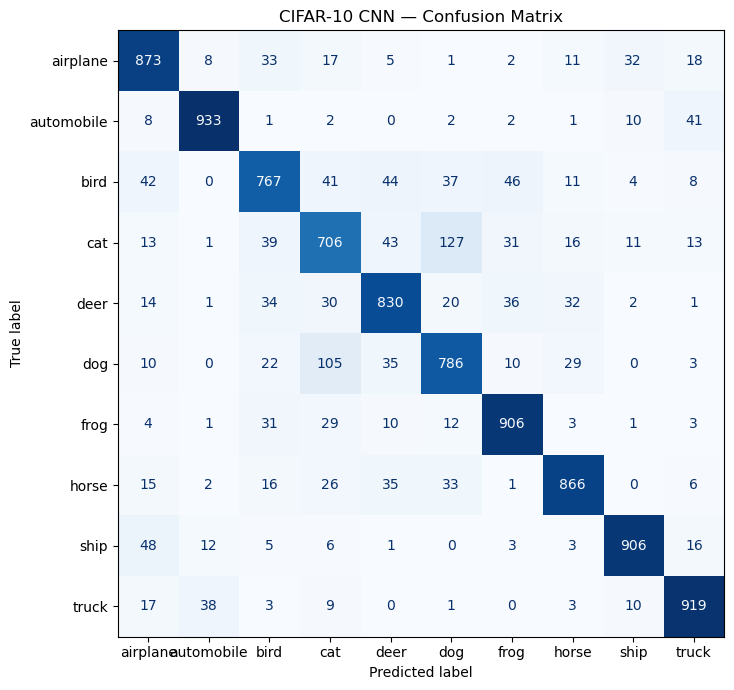

In [16]:
# ── 1.7  Confusion Matrix on Full Test Set ────────────────────────────────────
all_preds, all_labels = [], []
cnn.eval()
with torch.no_grad():
    for imgs, lbls in val_loader:
        preds = cnn(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASSES))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=CLASSES,
    cmap='Blues', colorbar=False, ax=ax
)
ax.set_title('CIFAR-10 CNN — Confusion Matrix')
plt.tight_layout(); plt.show()

In [17]:
# ── 2.1  Load Pretrained ResNet-18 & Replace Head ────────────────────────────
resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

# Strategy A: Freeze entire backbone
for param in resnet.parameters():
    param.requires_grad = False

# Replace final FC for 10-class CIFAR-10
resnet.fc = nn.Sequential(
    nn.Linear(resnet.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 10)
)
resnet = resnet.to(DEVICE)

frozen  = sum(p.numel() for p in resnet.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'Frozen params   : {frozen:,}')
print(f'Trainable params: {trainable:,}')
print(f'Training {trainable/(frozen+trainable)*100:.2f}% of total weights')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\yajne/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:32<00:00, 1.43MB/s]

Frozen params   : 11,176,512
Trainable params: 133,898
Training 1.18% of total weights


In [18]:
# ── 2.2  Fine-Tune Only the Head (fast!) ──────────────────────────────────────
# Resize CIFAR-10 images to 224x224 for ResNet
resnet_tf = T.Compose([
    T.Resize(224),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD)
])
rn_ds     = CIFAR10(root='./data', train=True,  download=False, transform=resnet_tf)
rn_val_ds = CIFAR10(root='./data', train=False, download=False, transform=T.Compose([T.Resize(224), T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)]))

# Use a small subset for speed
subset_idx = list(range(2000))
rn_train = torch.utils.data.Subset(rn_ds, subset_idx)
rn_val   = torch.utils.data.Subset(rn_val_ds, list(range(500)))

rn_loader     = DataLoader(rn_train, batch_size=32, shuffle=True)
rn_val_loader = DataLoader(rn_val,   batch_size=64, shuffle=False)

opt_rn = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-3)
crit   = nn.CrossEntropyLoss()

rn_accs = []
for epoch in range(1, 6):
    resnet.train()
    for imgs, lbls in rn_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        opt_rn.zero_grad()
        crit(resnet(imgs), lbls).backward()
        opt_rn.step()

    resnet.eval()
    correct = tot = 0
    with torch.no_grad():
        for imgs, lbls in rn_val_loader:
            preds = resnet(imgs.to(DEVICE)).argmax(1).cpu()
            correct += (preds == lbls).sum().item(); tot += lbls.size(0)
    acc = correct / tot
    rn_accs.append(acc)
    print(f'ResNet Epoch {epoch} | Val Acc: {acc:.4f}')

print(f'\nTransfer Learning: {rn_accs[-1]:.4f} accuracy with {trainable:,} trainable params')

ResNet Epoch 1 | Val Acc: 0.6420
ResNet Epoch 2 | Val Acc: 0.6640
ResNet Epoch 3 | Val Acc: 0.7080
ResNet Epoch 4 | Val Acc: 0.7140
ResNet Epoch 5 | Val Acc: 0.7160

Transfer Learning: 0.7160 accuracy with 133,898 trainable params


In [19]:
# ── 3.1  Tokenisation Deep Dive ───────────────────────────────────────────────
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained('bert-base-uncased')

sentences = [
    "Transfer learning rocks!",
    "The tokenizer splits words into subword units.",
    "Unbelievable results!"
]

for sent in sentences:
    enc    = tok(sent, return_tensors='pt')
    tokens = tok.convert_ids_to_tokens(enc['input_ids'][0])
    print(f'Text  : {sent}')
    print(f'Tokens: {tokens}')
    print(f'IDs   : {enc["input_ids"][0].tolist()}')
    print()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Text  : Transfer learning rocks!
Tokens: ['[CLS]', 'transfer', 'learning', 'rocks', '!', '[SEP]']
IDs   : [101, 4651, 4083, 5749, 999, 102]

Text  : The tokenizer splits words into subword units.
Tokens: ['[CLS]', 'the', 'token', '##izer', 'splits', 'words', 'into', 'sub', '##word', 'units', '.', '[SEP]']
IDs   : [101, 1996, 19204, 17629, 19584, 2616, 2046, 4942, 18351, 3197, 1012, 102]

Text  : Unbelievable results!
Tokens: ['[CLS]', 'unbelievable', 'results', '!', '[SEP]']
IDs   : [101, 23653, 3463, 999, 102]



In [20]:
# ── 3.2  Zero-Shot Pipelines ──────────────────────────────────────────────────

# Sentiment Analysis
sentiment_pipe = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english'
)
texts = [
    "Machine learning is incredibly powerful and exciting!",
    "This model is terribly slow and keeps crashing.",
    "The results were okay, nothing special.",
    "Absolutely loved the tutorial — very clear and well structured."
]
results = sentiment_pipe(texts)
print('=== Sentiment Analysis ===')
for t, r in zip(texts, results):
    print(f'  [{r["label"]:9s} {r["score"]:.3f}] {t[:55]}...')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

=== Sentiment Analysis ===
  [POSITIVE  1.000] Machine learning is incredibly powerful and exciting!...
  [NEGATIVE  0.997] This model is terribly slow and keeps crashing....
  [NEGATIVE  0.992] The results were okay, nothing special....
  [POSITIVE  1.000] Absolutely loved the tutorial — very clear and well str...


In [21]:
# ── 3.3  Named Entity Recognition ────────────────────────────────────────────
ner_pipe = pipeline(
    'ner',
    model='dbmdz/bert-large-cased-finetuned-conll03-english',
    aggregation_strategy='simple'
)

test_sentences = [
    "Elon Musk founded Tesla and SpaceX in California.",
    "Anthropic is an AI safety company based in San Francisco.",
    "The PyTorch framework was developed by Meta AI Research."
]

print('=== Named Entity Recognition ===')
for sent in test_sentences:
    entities = ner_pipe(sent)
    print(f'\nText: {sent}')
    for e in entities:
        print(f'  {e["entity_group"]:5s} → "{e["word"]}" (score: {e["score"]:.3f})')

config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

=== Named Entity Recognition ===

Text: Elon Musk founded Tesla and SpaceX in California.
  PER   → "Elon Musk" (score: 0.997)
  ORG   → "Tesla" (score: 0.990)
  ORG   → "SpaceX" (score: 0.998)
  LOC   → "California" (score: 1.000)

Text: Anthropic is an AI safety company based in San Francisco.
  ORG   → "Anthropic" (score: 0.987)
  MISC  → "AI" (score: 0.547)
  LOC   → "San Francisco" (score: 0.998)

Text: The PyTorch framework was developed by Meta AI Research.
  MISC  → "P" (score: 0.674)
  ORG   → "##yTor" (score: 0.596)
  MISC  → "##ch" (score: 0.547)
  ORG   → "Meta AI Research" (score: 0.996)


In [22]:
# ── 3.4  Fine-Tune DistilBERT on SST-2 ───────────────────────────────────────
MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load SST-2 (movie sentiment)
raw_ds = load_dataset('glue', 'sst2')
print('Dataset splits:', raw_ds)

def tokenize_fn(batch):
    return tokenizer(batch['sentence'], truncation=True, max_length=128)

tokenized = raw_ds.map(tokenize_fn, batched=True)
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print('\nSample tokenised entry:')
sample = tokenized['train'][0]
print(f'  input_ids shape : {sample["input_ids"].shape}')
print(f'  label           : {sample["labels"].item()}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Dataset splits: DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]


Sample tokenised entry:
  input_ids shape : torch.Size([10])
  label           : 0


In [23]:
# ── 3.5  HuggingFace Trainer API ─────────────────────────────────────────────
from transformers import AutoModelForSequenceClassification
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds)}

model_ft = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

training_args = TrainingArguments(
    output_dir         = './results/distilbert-sst2',
    num_train_epochs   = 2,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    evaluation_strategy = 'epoch',
    save_strategy       = 'epoch',
    load_best_model_at_end = True,
    learning_rate      = 2e-5,
    weight_decay       = 0.01,
    warmup_ratio       = 0.1,
    logging_steps      = 100,
    report_to          = 'none',
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model          = model_ft,
    args           = training_args,
    train_dataset  = tokenized['train'].select(range(5000)),  # subset for speed
    eval_dataset   = tokenized['validation'],
    tokenizer      = tokenizer,
    data_collator  = data_collator,
    compute_metrics= compute_metrics,
)

trainer.train()
eval_results = trainer.evaluate()
print(f"\nFinal eval accuracy: {eval_results['eval_accuracy']:.4f}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
# ── 3.6  Inference with Fine-Tuned Model ──────────────────────────────────────
ft_pipe = pipeline(
    'text-classification',
    model=model_ft,
    tokenizer=tokenizer
)

custom_texts = [
    "This was the best movie I have seen all year!",
    "Terrible pacing, weak plot, disappointing ending.",
    "An average film — not great, not terrible."
]

print('=== Fine-Tuned DistilBERT Predictions ===')
id2label = {0: 'NEGATIVE', 1: 'POSITIVE'}
for text in custom_texts:
    res = ft_pipe(text)[0]
    print(f'  [{res["label"]:10s} {res["score"]:.4f}] {text}')

In [ ]:
# ── 5.1  Save Required Artefacts ─────────────────────────────────────────────
# We'll deploy the Day 1 KNN Iris model as a REST API
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import joblib, os

os.makedirs('app', exist_ok=True)

iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_tr)
knn    = KNeighborsClassifier(n_neighbors=5).fit(scaler.transform(X_tr), y_tr)

joblib.dump(scaler, 'app/scaler_iris.pkl')
joblib.dump(knn,    'app/knn_iris.pkl')
print(f'✅ Artefacts saved in ./app/')
print(f'   Model accuracy: {knn.score(scaler.transform(X_te), y_te):.4f}')

In [ ]:
# ── 5.2  Write FastAPI Application ───────────────────────────────────────────
main_py = '''
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from contextlib import asynccontextmanager
from typing import List
import joblib
import numpy as np

# ── Schemas ──────────────────────────────────────────────────────────────────
class IrisFeatures(BaseModel):
    sepal_length: float = Field(..., gt=0, description="Sepal length in cm")
    sepal_width:  float = Field(..., gt=0, description="Sepal width in cm")
    petal_length: float = Field(..., gt=0, description="Petal length in cm")
    petal_width:  float = Field(..., gt=0, description="Petal width in cm")

class BatchRequest(BaseModel):
    samples: List[IrisFeatures]

class PredictionResponse(BaseModel):
    species:    str
    class_id:   int
    confidence: float

# ── App Lifespan (load model once at startup) ─────────────────────────────────
ml_objects = {}

@asynccontextmanager
async def lifespan(app: FastAPI):
    ml_objects["model"]  = joblib.load("app/knn_iris.pkl")
    ml_objects["scaler"] = joblib.load("app/scaler_iris.pkl")
    ml_objects["labels"] = ["setosa", "versicolor", "virginica"]
    print("✅ Model loaded and ready.")
    yield
    ml_objects.clear()

app = FastAPI(
    title="Iris Species Classifier API",
    description="Predict Iris species from flower measurements.",
    version="1.0.0",
    lifespan=lifespan
)

# ── Endpoints ────────────────────────────────────────────────────────────────
@app.get("/health")
def health_check():
    return {"status": "ok", "model_loaded": "model" in ml_objects}

@app.post("/predict", response_model=PredictionResponse)
async def predict(data: IrisFeatures):
    try:
        X = np.array([[data.sepal_length, data.sepal_width,
                       data.petal_length, data.petal_width]])
        X_sc  = ml_objects["scaler"].transform(X)
        pred  = ml_objects["model"].predict(X_sc)[0]
        proba = ml_objects["model"].predict_proba(X_sc)[0].max()
        return PredictionResponse(
            species=ml_objects["labels"][pred],
            class_id=int(pred),
            confidence=round(float(proba), 4)
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.post("/predict/batch")
async def predict_batch(batch: BatchRequest):
    X = np.array([[s.sepal_length, s.sepal_width, s.petal_length, s.petal_width]
                  for s in batch.samples])
    X_sc   = ml_objects["scaler"].transform(X)
    preds  = ml_objects["model"].predict(X_sc)
    probas = ml_objects["model"].predict_proba(X_sc).max(axis=1)
    return [{"species": ml_objects["labels"][p], "class_id": int(p),
             "confidence": round(float(c), 4)}
            for p, c in zip(preds, probas)]
'''

with open('app/main.py', 'w') as f:
    f.write(main_py.strip())
print('✅ app/main.py written')
print(main_py[:500] + '...')

In [ ]:
# ── 5.3  Write Dockerfile ────────────────────────────────────────────────────
dockerfile = '''FROM python:3.10-slim

WORKDIR /code

# Install dependencies first (layer caching)
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application files
COPY app/ ./app/

EXPOSE 8000

# Health check
HEALTHCHECK --interval=30s --timeout=10s --start-period=5s --retries=3 \\
  CMD curl -f http://localhost:8000/health || exit 1

CMD ["uvicorn", "app.main:app", "--host", "0.0.0.0", "--port", "8000"]
'''

requirements = '''fastapi>=0.110.0
uvicorn[standard]>=0.27.0
pydantic>=2.0.0
scikit-learn>=1.3.0
numpy>=1.24.0
joblib>=1.3.0
httpx>=0.27.0
'''

with open('Dockerfile', 'w') as f:
    f.write(dockerfile)
with open('requirements.txt', 'w') as f:
    f.write(requirements)

print('✅ Dockerfile written')
print('✅ requirements.txt written')
print('\n📋 Dockerfile:')
print(dockerfile)

In [ ]:
# ── 5.4  Test API Locally (without Docker) ───────────────────────────────────
# Simulate what FastAPI does — test the prediction logic directly
import joblib
import numpy as np

model_loaded  = joblib.load('app/knn_iris.pkl')
scaler_loaded = joblib.load('app/scaler_iris.pkl')
LABELS = ['setosa', 'versicolor', 'virginica']

def mock_predict(sepal_length, sepal_width, petal_length, petal_width):
    X    = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    X_sc = scaler_loaded.transform(X)
    pred  = model_loaded.predict(X_sc)[0]
    proba = model_loaded.predict_proba(X_sc)[0].max()
    return {'species': LABELS[pred], 'class_id': int(pred), 'confidence': round(float(proba), 4)}

test_cases = [
    (5.1, 3.5, 1.4, 0.2),  # setosa
    (6.3, 2.8, 4.9, 1.5),  # versicolor
    (7.2, 3.0, 5.8, 1.8),  # virginica
]

print('=== Mock API Predictions ===')
for tc in test_cases:
    result = mock_predict(*tc)
    print(f'  Input: {tc} → {result}')

In [ ]:
# ── 5.5  Docker Build & Run Commands ─────────────────────────────────────────
print('''
=== Docker Commands to Build & Run ===

# 1. Build the Docker image
docker build -t iris-classifier:v1 .

# 2. Run the container
docker run -p 8000:8000 iris-classifier:v1

# 3. Test the API (in another terminal)
curl -X POST http://localhost:8000/predict \\
  -H "Content-Type: application/json" \\
  -d \'{ "sepal_length": 5.1, "sepal_width": 3.5,
          "petal_length": 1.4, "petal_width": 0.2 }\'

# 4. Check health
curl http://localhost:8000/health

# 5. Open Swagger docs
open http://localhost:8000/docs
''')

In [ ]:
# ── 5.6  Automated API Test with httpx ───────────────────────────────────────
# Run this AFTER starting uvicorn: uvicorn app.main:app --reload
# Uncomment when the server is running.

'''
import httpx

BASE = "http://localhost:8000"

# Health check
r = httpx.get(f"{BASE}/health")
print("Health:", r.json())

# Single prediction
payload = {"sepal_length": 5.1, "sepal_width": 3.5,
           "petal_length": 1.4, "petal_width":  0.2}
r = httpx.post(f"{BASE}/predict", json=payload)
print("Single:", r.json())

# Batch prediction
batch = {"samples": [
    {"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2},
    {"sepal_length": 6.3, "sepal_width": 2.8, "petal_length": 4.9, "petal_width": 1.5},
    {"sepal_length": 7.2, "sepal_width": 3.0, "petal_length": 5.8, "petal_width": 1.8},
]}
r = httpx.post(f"{BASE}/predict/batch", json=batch)
print("Batch :", r.json())
'''
print('Uncomment the above block and run after starting the FastAPI server.')